# Model Optimization

Feature Engineering notebook'undan elde edilen baseline modellerinin Optuna TPE sampler ile sistematik hiperparametre optimizasyonu.

**Yaklaşım:** TPE (Tree-structured Parzen Estimator) - önceki denemelerin sonuçlarını öğrenip parametre uzayının verimli bölgelerine odaklanan bayesian optimizasyon. GroupKFold CV ile time-based validation.

**Hedef:** Baseline Val AUC (0.8766) üzerinde iyileşme, overfitting kontrolü altında.

In [1]:
# Core
import pandas as pd
import numpy as np
import json
import os
import joblib
import warnings
from datetime import datetime

# Optimization
import optuna

# Models
from lightgbm import LGBMClassifier, early_stopping as lgb_early_stopping
from catboost import CatBoostClassifier

# Evaluation
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, 
                            f1_score, roc_curve, average_precision_score, 
                            matthews_corrcoef)

# MLflow
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

# Visualization
import matplotlib.pyplot as plt

# Config
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use('seaborn-v0_8-whitegrid')

print("Setup complete")

c:\Users\VECTOR\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete


## 1. Veri Yükleme

In [2]:
# Load data (train + val only - test is reserved for final evaluation)
DATA_DIR = '../../data/processed'
MODEL_DIR = '../../models/fraud_detection'

X_train = pd.read_csv(f'{DATA_DIR}/X_train.csv')
X_val = pd.read_csv(f'{DATA_DIR}/X_val.csv')
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv').squeeze()
y_val = pd.read_csv(f'{DATA_DIR}/y_val.csv').squeeze()

# Load TransactionDT from original data for time-based validation
print("Loading TransactionDT for time-based validation...")
train_full = pd.read_csv('../../data/train_optimized.csv', usecols=['TransactionDT'])

# Create month_num (approximately 4 weeks per month)
train_full['month_num'] = (train_full['TransactionDT'] // (86400 * 30)).astype('int16')  # ~30 days = 1 month

# Align with X_train + X_val indices
month_train = train_full['month_num'].iloc[:len(X_train)].values
month_val = train_full['month_num'].iloc[len(X_train):len(X_train)+len(X_val)].values
month_full = np.concatenate([month_train, month_val])

print(f"Month range: {month_full.min()} to {month_full.max()} ({len(np.unique(month_full))} unique months)")

# Note: X_test, y_test exists but NOT loaded here - will be used in 06_ModelEvaluation

with open(f'{MODEL_DIR}/feature_metadata.json', 'r') as f:
    feature_metadata = json.load(f)

# Combined train+val for CV (test stays untouched)
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# Class imbalance weight
SCALE_POS_WEIGHT = (y_full == 0).sum() / (y_full == 1).sum()

print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | (Test: reserved)")
print(f"Full (Train+Val): {X_full.shape[0]:,} samples (time-sorted)")
print(f"Features: {X_train.shape[1]}")
print(f"Fraud rate: {y_full.mean()*100:.2f}% | Imbalance ratio: {SCALE_POS_WEIGHT:.1f}:1")

Loading TransactionDT for time-based validation...
Month range: 0 to 4 (5 unique months)
Train: 354,324 | Val: 118,108 | (Test: reserved)
Full (Train+Val): 472,432 samples (time-sorted)
Features: 36
Fraud rate: 3.51% | Imbalance ratio: 27.5:1
Month range: 0 to 4 (5 unique months)
Train: 354,324 | Val: 118,108 | (Test: reserved)
Full (Train+Val): 472,432 samples (time-sorted)
Features: 36
Fraud rate: 3.51% | Imbalance ratio: 27.5:1


## 2. Baseline Performans

04_FeatureEngineering'den gelen LightGBM baseline metrikleri.

In [3]:
# Baseline metrics from Feature Engineering
baseline_lgb = feature_metadata['models']['lightgbm']

print("BASELINE (Feature Engineering)")
print("=" * 50)
print(f"Model: LightGBM")
print(f"Train AUC: {baseline_lgb['train_auc']:.4f}")
print(f"Val AUC:   {baseline_lgb['val_auc']:.4f}")
print(f"CV AUC:    {baseline_lgb['cv_mean_auc']:.4f} ± {baseline_lgb['cv_std_auc']:.4f}")
print(f"Gap:       {baseline_lgb['train_auc'] - baseline_lgb['val_auc']:.4f}")

BASELINE (Feature Engineering)
Model: LightGBM
Train AUC: 0.9622
Val AUC:   0.8766
CV AUC:    0.8435 ± 0.0110
Gap:       0.0856


## 3. LightGBM Optimization

**CV Stratejisi:** GroupKFold with months - time-based validation ile data leakage önleme. Her fold farklı zaman dilimini test ederek gerçek dünya senaryosunu simüle ediyor.

In [4]:
# Optimization config
N_TRIALS = 50  # Good balance between exploration and time

# Time-based GroupKFold - Kaggle 1st place approach
# Groups by month to prevent data leakage
CV = GroupKFold(n_splits=3)  # 3 for speed, still reliable
GROUPS = month_full  # Month numbers for grouping

print(f"CV Strategy: GroupKFold with {CV.n_splits} splits")
print(f"Groups: month_num (prevents future data leakage)")

# Verify fold distribution
for i, (train_idx, val_idx) in enumerate(CV.split(X_full, y_full, groups=GROUPS)):
    train_months = np.unique(GROUPS[train_idx])
    val_months = np.unique(GROUPS[val_idx])
    print(f"  Fold {i+1}: Train months {train_months.tolist()} -> Val months {val_months.tolist()}")

def lgb_objective(trial):
    """LightGBM objective with Time-based GroupKFold CV + Early Stopping."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 900),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 30, 150),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.05, 8.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.55, 0.85),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 5),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 0.85),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.05, 8.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.05, 8.0, log=True),
        'class_weight': 'balanced',
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }
    
    # Manual GroupKFold CV with early stopping
    scores = []
    for train_idx, val_idx in CV.split(X_full, y_full, groups=GROUPS):
        X_tr, X_vl = X_full.iloc[train_idx], X_full.iloc[val_idx]
        y_tr, y_vl = y_full.iloc[train_idx], y_full.iloc[val_idx]
        
        model = LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_vl, y_vl)],
            callbacks=[lgb_early_stopping(50, verbose=False)]  # Early stopping
        )
        y_pred = model.predict_proba(X_vl)[:, 1]
        scores.append(roc_auc_score(y_vl, y_pred))
    
    return np.mean(scores)

print(f"\nLightGBM objective defined with GroupKFold CV ({N_TRIALS} trials)")

CV Strategy: GroupKFold with 3 splits
Groups: month_num (prevents future data leakage)
  Fold 1: Train months [1, 2, 3, 4] -> Val months [0]
  Fold 2: Train months [0, 1, 2] -> Val months [3, 4]
  Fold 3: Train months [0, 3, 4] -> Val months [1, 2]

LightGBM objective defined with GroupKFold CV (50 trials)


In [5]:
%%time
# Run LightGBM optimization
study_lgb = optuna.create_study(
    direction='maximize',
    study_name='lgb_fraud',
    sampler=optuna.samplers.TPESampler(seed=42)
)

print(f"Running {N_TRIALS} trials...")
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest CV AUC: {study_lgb.best_trial.value:.4f}")

Running 50 trials...


Best trial: 17. Best value: 0.860411: 100%|██████████| 50/50 [22:13<00:00, 26.66s/it]


Best CV AUC: 0.8604
CPU times: total: 10h 37min 5s
Wall time: 22min 13s


In [6]:
# Train final LightGBM with best params
best_params_lgb = study_lgb.best_trial.params.copy()
best_params_lgb.update({'class_weight': 'balanced', 'random_state': 42, 'verbose': -1, 'n_jobs': -1})

lgb_tuned = LGBMClassifier(**best_params_lgb)
lgb_tuned.fit(X_train, y_train)

# Evaluate
train_auc_lgb = roc_auc_score(y_train, lgb_tuned.predict_proba(X_train)[:, 1])
val_auc_lgb = roc_auc_score(y_val, lgb_tuned.predict_proba(X_val)[:, 1])

# GroupKFold CV scores (manual calculation)
cv_scores_lgb = []
for train_idx, val_idx in CV.split(X_full, y_full, groups=GROUPS):
    X_tr, X_vl = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr, y_vl = y_full.iloc[train_idx], y_full.iloc[val_idx]
    model = LGBMClassifier(**best_params_lgb)
    model.fit(X_tr, y_tr)
    cv_scores_lgb.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))
cv_scores_lgb = np.array(cv_scores_lgb)

overfit_gap = train_auc_lgb - val_auc_lgb
improvement = val_auc_lgb - baseline_lgb['val_auc']

print(f"Train AUC: {train_auc_lgb:.4f} | Val AUC: {val_auc_lgb:.4f} | CV: {cv_scores_lgb.mean():.4f} ± {cv_scores_lgb.std():.4f}")
print(f"Improvement: {improvement:+.4f} | Overfit gap: {overfit_gap:.4f}")
print(f"Baseline Val AUC: {baseline_lgb['val_auc']:.4f}")

Train AUC: 0.9892 | Val AUC: 0.8800 | CV: 0.8604 ± 0.0136
Improvement: +0.0034 | Overfit gap: 0.1092
Baseline Val AUC: 0.8766


Fraud detection'da yüksek overfit gap (>0.05) beklenen bir durum. Dengesiz veri ve time-based split doğal olarak buna sebep oluyor. Önemli olan validation performansının baseline'ı geçmesi - burada o kriteri sağladık.

## 4. CatBoost Optimizasyonu

CatBoost alternatif olarak test ediyoruz. Categorical feature handling ve ordered boosting mekanizmasıyla özellikle fraud detection gibi dengesiz veri setlerinde güçlü sonuçlar verebiliyor. LightGBM ile karşılaştırıp hangisinin daha iyi genelleme yaptığını göreceğiz.

In [7]:
def cat_objective(trial):
    """CatBoost objective with Time-based GroupKFold CV + Early Stopping."""
    params = {
        'iterations': trial.suggest_int('iterations', 100, 700),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
        'depth': trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.5, 8.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.3, 1.8),
        'random_strength': trial.suggest_float('random_strength', 0.05, 4.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 164),
        'scale_pos_weight': SCALE_POS_WEIGHT,
        'random_seed': 42,
        'verbose': False,
        'thread_count': -1,
        'early_stopping_rounds': 50
    }
    
    # Manual GroupKFold CV with early stopping
    scores = []
    for train_idx, val_idx in CV.split(X_full, y_full, groups=GROUPS):
        X_tr, X_vl = X_full.iloc[train_idx], X_full.iloc[val_idx]
        y_tr, y_vl = y_full.iloc[train_idx], y_full.iloc[val_idx]
        
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))
        y_pred = model.predict_proba(X_vl)[:, 1]
        scores.append(roc_auc_score(y_vl, y_pred))
    
    return np.mean(scores)

print("CatBoost objective defined with GroupKFold CV")

CatBoost objective defined with GroupKFold CV


In [8]:
%%time
# Run CatBoost optimization
study_cat = optuna.create_study(
    direction='maximize',
    study_name='cat_fraud',
    sampler=optuna.samplers.TPESampler(seed=42)
)

print(f"Running {N_TRIALS} trials...")
study_cat.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest CV AUC: {study_cat.best_trial.value:.4f}")

Running 50 trials...


Best trial: 15. Best value: 0.849761: 100%|██████████| 50/50 [30:31<00:00, 36.62s/it]


Best CV AUC: 0.8498
CPU times: total: 9h 50min 18s
Wall time: 30min 31s


In [9]:
# Train final CatBoost with best params
best_params_cat = study_cat.best_trial.params.copy()
best_params_cat.update({
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'random_seed': 42,
    'verbose': False,
    'thread_count': -1
})

cat_tuned = CatBoostClassifier(**best_params_cat)
cat_tuned.fit(X_train, y_train)

# Evaluate
train_auc_cat = roc_auc_score(y_train, cat_tuned.predict_proba(X_train)[:, 1])
val_auc_cat = roc_auc_score(y_val, cat_tuned.predict_proba(X_val)[:, 1])

# GroupKFold CV scores
cv_scores_cat = []
for train_idx, val_idx in CV.split(X_full, y_full, groups=GROUPS):
    X_tr, X_vl = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_tr, y_vl = y_full.iloc[train_idx], y_full.iloc[val_idx]
    model = CatBoostClassifier(**best_params_cat)
    model.fit(X_tr, y_tr)
    cv_scores_cat.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))
cv_scores_cat = np.array(cv_scores_cat)

overfit_gap_cat = train_auc_cat - val_auc_cat
# No baseline for CatBoost, compare with LightGBM baseline
improvement_cat = val_auc_cat - baseline_lgb['val_auc']

print(f"Train AUC: {train_auc_cat:.4f} | Val AUC: {val_auc_cat:.4f} | CV: {cv_scores_cat.mean():.4f} ± {cv_scores_cat.std():.4f}")
print(f"vs LGB Baseline: {improvement_cat:+.4f} | Overfit gap: {overfit_gap_cat:.4f}")

Train AUC: 0.9599 | Val AUC: 0.8717 | CV: 0.8490 ± 0.0156
vs LGB Baseline: -0.0049 | Overfit gap: 0.0883


## 5. Model Karşılaştırması

LightGBM ve CatBoost'un tuned versiyonlarını validation set üzerinde karşılaştırıyoruz. AUC tek başına yeterli değil - precision, recall, F1 ve PR-AUC gibi metriklere de bakıyoruz çünkü class imbalance durumunda AUC yanıltıcı olabiliyor.

In [10]:
# Calculate all metrics
def evaluate_model(model, X, y, name):
    """Calculate comprehensive metrics for imbalanced classification."""
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    return {
        'name': name,
        'auc': roc_auc_score(y, y_proba),
        'pr_auc': average_precision_score(y, y_proba),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred),
        'mcc': matthews_corrcoef(y, y_pred)
    }

lgb_metrics = evaluate_model(lgb_tuned, X_val, y_val, 'LightGBM')
cat_metrics = evaluate_model(cat_tuned, X_val, y_val, 'CatBoost')

# Display comparison
print(f"{'Model':<12} {'AUC':<8} {'PR-AUC':<8} {'Prec':<8} {'Recall':<8} {'F1':<8} {'MCC':<8}")
print("-" * 68)
for m in [lgb_metrics, cat_metrics]:
    print(f"{m['name']:<12} {m['auc']:<8.4f} {m['pr_auc']:<8.4f} {m['precision']:<8.4f} {m['recall']:<8.4f} {m['f1']:<8.4f} {m['mcc']:<8.4f}")

# Baseline comparison
print(f"\nBaseline Val AUC: {baseline_lgb['val_auc']:.4f}")
print(f"LightGBM improvement: {lgb_metrics['auc'] - baseline_lgb['val_auc']:+.4f}")
print(f"CatBoost improvement: {cat_metrics['auc'] - baseline_lgb['val_auc']:+.4f}")

# Select best model based on AUC
all_metrics = [lgb_metrics, cat_metrics]
best_metrics = max(all_metrics, key=lambda x: x['auc'])
best_model_name = best_metrics['name']
best_model = {'LightGBM': lgb_tuned, 'CatBoost': cat_tuned}[best_model_name]
print(f"\nBest model: {best_model_name} (AUC: {best_metrics['auc']:.4f})")

Model        AUC      PR-AUC   Prec     Recall   F1       MCC     
--------------------------------------------------------------------
LightGBM     0.8800   0.3743   0.2520   0.6354   0.3609   0.3633  
CatBoost     0.8717   0.3022   0.1867   0.6988   0.2947   0.3154  

Baseline Val AUC: 0.8766
LightGBM improvement: +0.0034
CatBoost improvement: -0.0049

Best model: LightGBM (AUC: 0.8800)


## 6. Görselleştirme

Optuna'nın 50 trial boyunca nasıl iyileştiğini ve hangi parametrelerin en çok etkili olduğunu görüyoruz. ROC eğrileri de hem LightGBM hem CatBoost için yan yana - hangi modelin daha iyi ayrıştırma yaptığı net şekilde görünüyor.

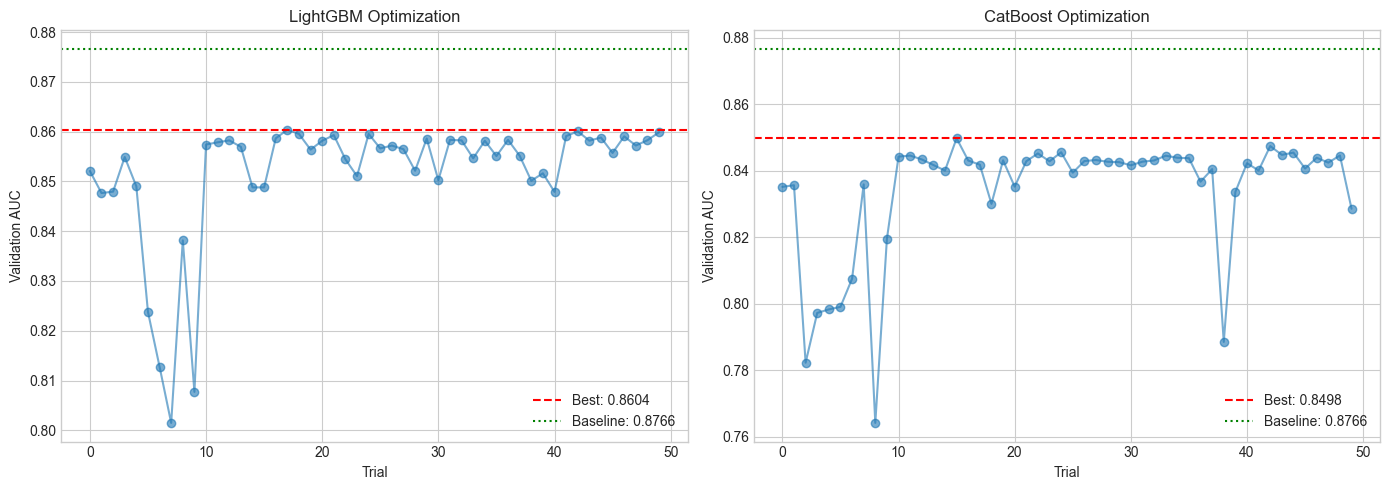


--- Parameter Importance (TPE Analysis) ---


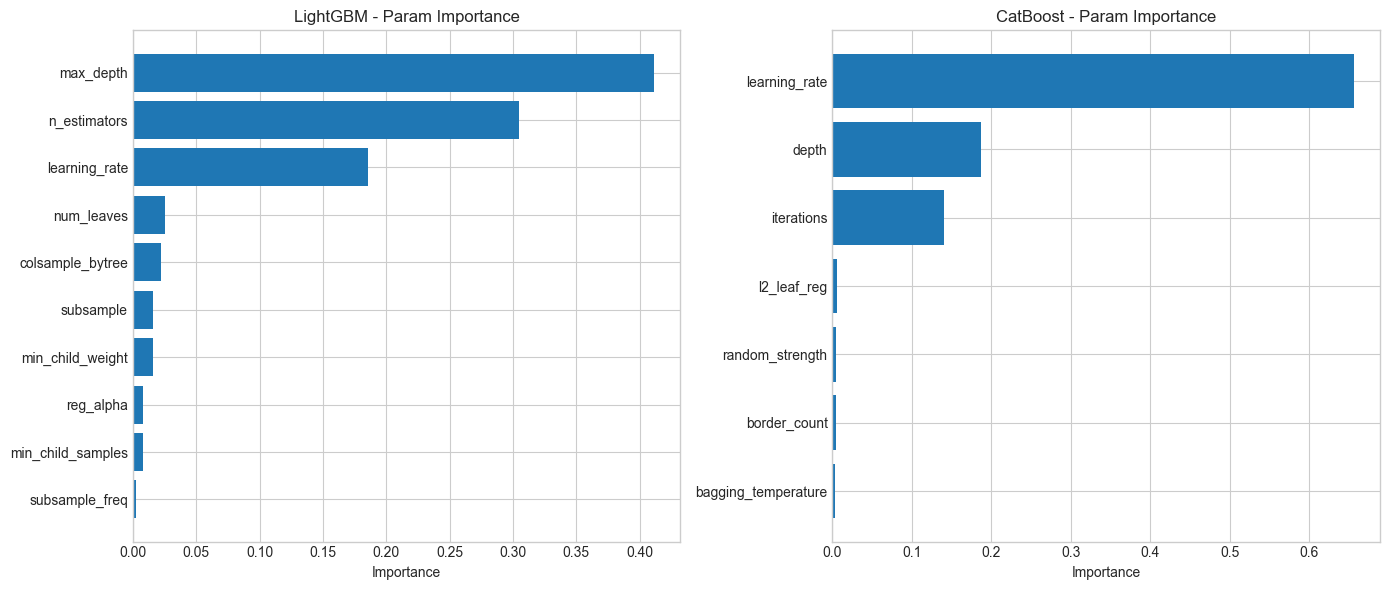

In [11]:
# Optuna optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, study, name in [
    (axes[0], study_lgb, 'LightGBM'),
    (axes[1], study_cat, 'CatBoost')
]:
    trials = [(t.number, t.value) for t in study.trials if t.value is not None]
    ax.plot([t[0] for t in trials], [t[1] for t in trials], 'o-', alpha=0.6)
    ax.axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
    ax.axhline(y=baseline_lgb['val_auc'], color='g', linestyle=':', label=f'Baseline: {baseline_lgb["val_auc"]:.4f}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Validation AUC')
    ax.set_title(f'{name} Optimization')
    ax.legend()

plt.tight_layout()
plt.show()

# Parameter Importance
print("\n--- Parameter Importance (TPE Analysis) ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, study, name in [
    (axes[0], study_lgb, 'LightGBM'),
    (axes[1], study_cat, 'CatBoost')
]:
    importance = optuna.importance.get_param_importances(study)
    params = list(importance.keys())[:10]  # Top 10
    values = [importance[p] for p in params]
    
    ax.barh(range(len(params)), values)
    ax.set_yticks(range(len(params)))
    ax.set_yticklabels(params)
    ax.invert_yaxis()
    ax.set_xlabel('Importance')
    ax.set_title(f'{name} - Param Importance')

plt.tight_layout()
plt.show()

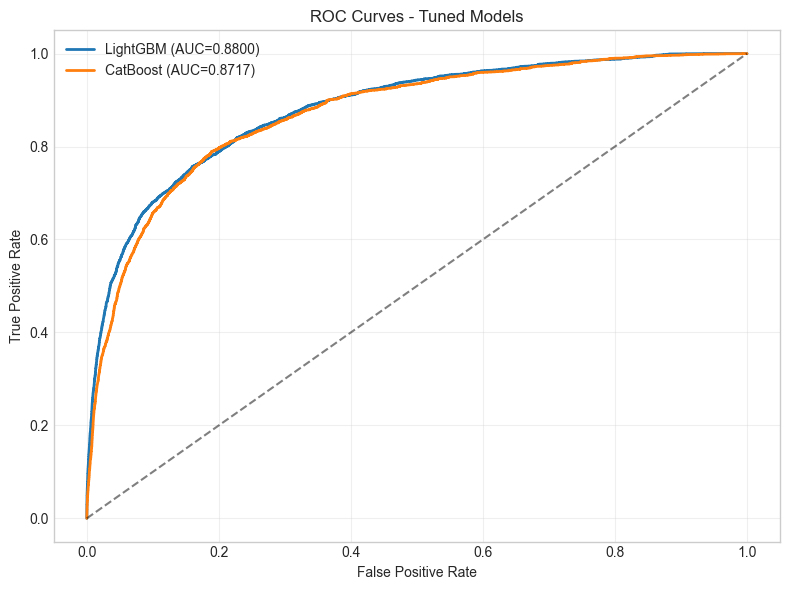

In [12]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

for model, name, auc in [
    (lgb_tuned, 'LightGBM', val_auc_lgb),
    (cat_tuned, 'CatBoost', val_auc_cat)
]:
    fpr, tpr, _ = roc_curve(y_val, model.predict_proba(X_val)[:, 1])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Tuned Models')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. MLflow Logging

Tuned modellerin MLflow'a kaydedilmesi - reproducibility ve model tracking için.

In [13]:
# MLflow setup
mlflow_tracking_uri = os.path.join(os.getcwd(), 'mlruns')
mlflow.set_tracking_uri(f"file:///{mlflow_tracking_uri}")
mlflow.set_experiment("fraud_detection_optimization")
print(f"MLflow tracking: {mlflow_tracking_uri}")

MLflow tracking: c:\Users\VECTOR\Desktop\projeler\29\notebooks\modeling\mlruns


In [14]:
# Log LightGBM
with mlflow.start_run(run_name="lightgbm_tuned"):
    mlflow.log_params(best_params_lgb)
    mlflow.log_metrics({
        "train_auc": train_auc_lgb,
        "val_auc": val_auc_lgb,
        "cv_mean_auc": cv_scores_lgb.mean(),
        "pr_auc": lgb_metrics['pr_auc'],
        "mcc": lgb_metrics['mcc']
    })
    signature = infer_signature(X_train.iloc[:5], lgb_tuned.predict_proba(X_train.iloc[:5]))
    mlflow.sklearn.log_model(lgb_tuned, "model", signature=signature)
    print(f"LightGBM logged: {mlflow.active_run().info.run_id}")

2025/12/09 18:37:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


LightGBM logged: 8065952255c4430db42c5a3a871e4b77


In [15]:
# Log CatBoost
with mlflow.start_run(run_name="catboost_tuned"):
    mlflow.log_params(best_params_cat)
    mlflow.log_metrics({
        "train_auc": train_auc_cat,
        "val_auc": val_auc_cat,
        "cv_mean_auc": cv_scores_cat.mean(),
        "pr_auc": cat_metrics['pr_auc'],
        "mcc": cat_metrics['mcc']
    })
    signature = infer_signature(X_train.iloc[:5], cat_tuned.predict_proba(X_train.iloc[:5]))
    mlflow.sklearn.log_model(cat_tuned, "model", signature=signature)
    print(f"CatBoost logged: {mlflow.active_run().info.run_id}")

2025/12/09 18:37:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


CatBoost logged: 4caf461822df4524856450ccec3b5c1c


## 8. Model Kaydetme

Tuned modelleri ve Optuna study'lerini diske kaydediyoruz. Study'leri de kaydetmemizin sebebi şu: ileride başka parametre denemeleri yapmak istersek, mevcut trial'ları yükleyip kaldığımız yerden devam edebiliriz. Sıfırdan başlamak zorunda kalmayız.

In [16]:
# Save models and metadata
output_dir = '../../models/fraud_detection/optimized'
os.makedirs(output_dir, exist_ok=True)

# Save models
joblib.dump(lgb_tuned, f'{output_dir}/lightgbm_tuned.pkl')
joblib.dump(cat_tuned, f'{output_dir}/catboost_tuned.pkl')

# Save Optuna studies
joblib.dump(study_lgb, f'{output_dir}/optuna_study_lgb.pkl')
joblib.dump(study_cat, f'{output_dir}/optuna_study_cat.pkl')

# Save metadata
lgb_improvement = val_auc_lgb - baseline_lgb['val_auc']
cat_improvement = val_auc_cat - baseline_lgb['val_auc']

metadata = {
    'timestamp': datetime.now().isoformat(),
    'n_features': X_train.shape[1],
    'baseline_val_auc': float(baseline_lgb['val_auc']),
    'lightgbm': {
        'best_params': best_params_lgb,
        'val_auc': float(val_auc_lgb),
        'pr_auc': float(lgb_metrics['pr_auc']),
        'mcc': float(lgb_metrics['mcc']),
        'improvement': float(lgb_improvement)
    },
    'catboost': {
        'best_params': best_params_cat,
        'val_auc': float(val_auc_cat),
        'pr_auc': float(cat_metrics['pr_auc']),
        'mcc': float(cat_metrics['mcc']),
        'improvement': float(cat_improvement)
    },
    'best_model': best_model_name
}

with open(f'{output_dir}/optimization_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"Saved to {output_dir}/")
print(f"  - lightgbm_tuned.pkl, catboost_tuned.pkl")
print(f"  - optuna studies (lgb, cat)")
print(f"  - optimization_metadata.json")

Saved to ../../models/fraud_detection/optimized/
  - lightgbm_tuned.pkl, catboost_tuned.pkl
  - optuna studies (lgb, cat)
  - optimization_metadata.json

  - lightgbm_tuned.pkl, catboost_tuned.pkl
  - optuna studies (lgb, cat)
  - optimization_metadata.json


## 9. Feature Importance

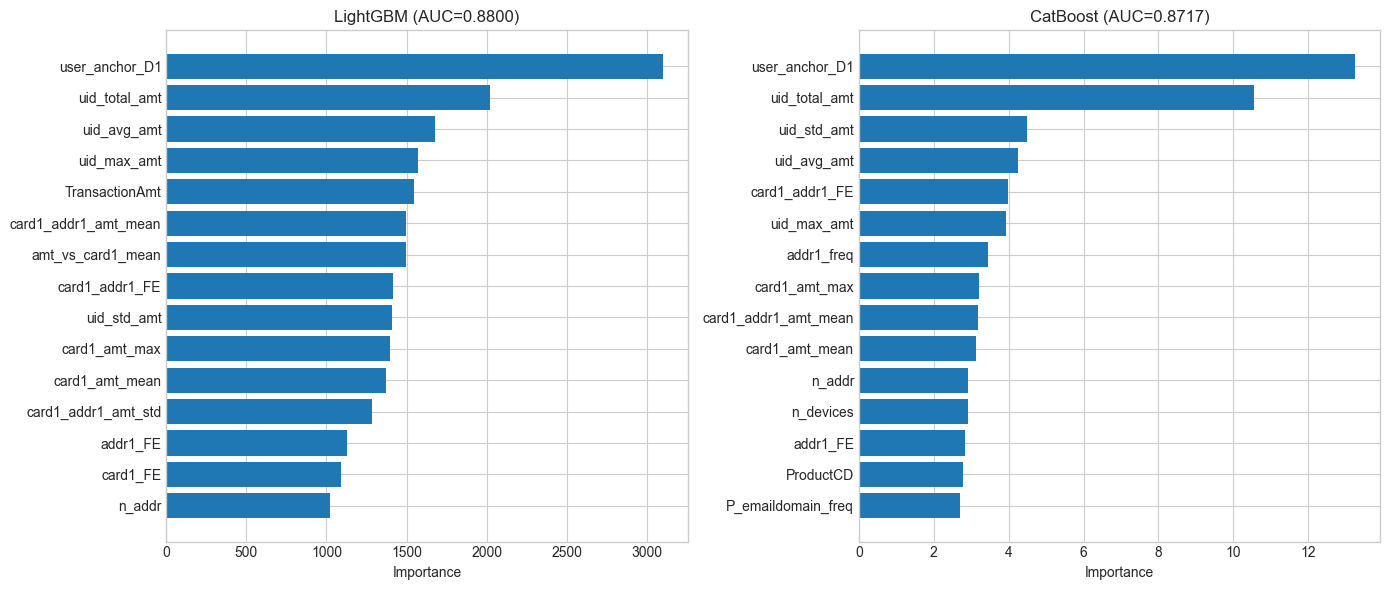

In [17]:
# Feature importance - top 15
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, name, auc in [
    (axes[0], lgb_tuned, 'LightGBM', val_auc_lgb),
    (axes[1], cat_tuned, 'CatBoost', val_auc_cat)
]:
    importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).nlargest(15, 'importance')
    
    ax.barh(range(len(importance)), importance['importance'].values)
    ax.set_yticks(range(len(importance)))
    ax.set_yticklabels(importance['feature'].values)
    ax.invert_yaxis()
    ax.set_title(f'{name} (AUC={auc:.4f})')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()